Задача 1. Оценивание стационарной плотности ансамбля
1. Для модели CIR или OU сгенерируйте траекторию процесса с большим финальным временем $T$ для достижения стационарного режима.

2. Реализуйте функцию `StationaryDistributionKernelEstimator`.

3. Постройте на одном графике теоретическую стационарную плотность $π(x)$ и три ядерные оценки с использованием различных ядер: гауссовского, равномерного и Епанечникова (параболического).

4. Сделайте выводы.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2, norm

Размер выборки: 90001
Ширина окна (Scott's rule): 0.0882


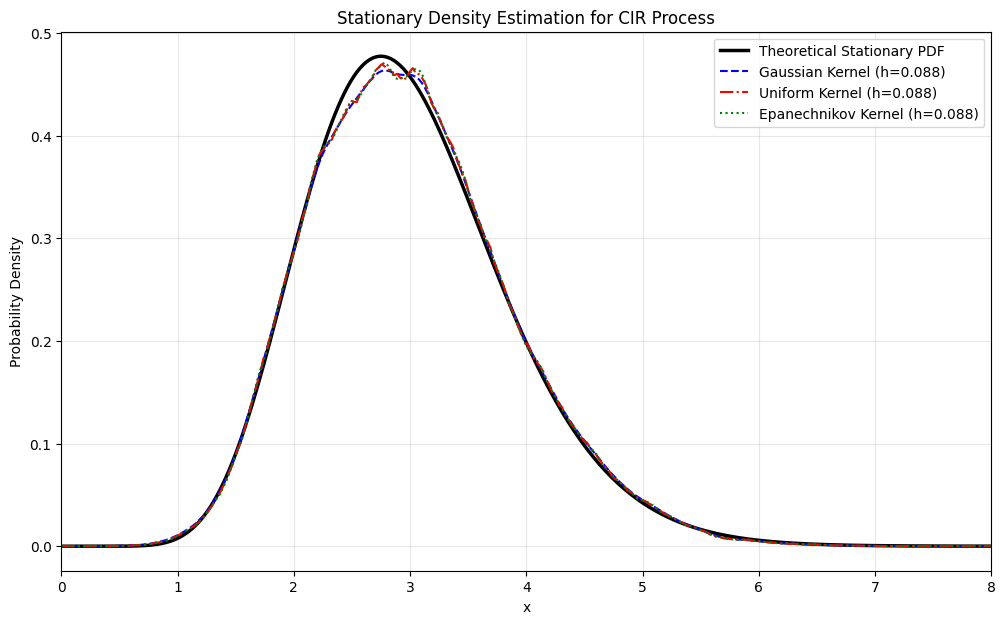

1. Все три ядерные оценки достаточно хорошо аппроксимируют теоретическую плотность при большом объеме выборки.
2. Гауссовское ядро дает наиболее гладкую оценку, но может иметь небольшие 'хвосты' за пределами области определения (x<0)
3. Равномерное ядро дает менее гладкую оценку, так как оно имеет разрывы.
4. Ядро Епанечникова: гладкое имеет конечный носитель, что часто делает его предпочтительным (меньшая дисперсия ошибки).
5. При правильном выборе ширины окна разница между ядрами визуально невелика для больших n.


In [ ]:
class CIRProcess:
    def __init__(self, params, T, Nt, x0=None):
    
        self.params = params
        self.T = T
        self.Nt = Nt
        self.dt = T / Nt
        self.x0 = x0 if x0 is not None else params[0] / params[1] 

    def simulate_euler(self):
        x = np.zeros(self.Nt + 1)
        x[0] = self.x0
        

        dW = np.random.normal(0, np.sqrt(self.dt), self.Nt)
        
        theta1, theta2, theta3 = self.params
        
        for i in range(self.Nt):
            x_curr = max(x[i], 0) 
            drift = (theta1 - theta2 * x_curr) * self.dt
            diffusion = theta3 * np.sqrt(x_curr) * dW[i]
            x[i+1] = x[i] + drift + diffusion
            
        return x

    def stationary_pdf(self, x_vals):
        theta1, theta2, theta3 = self.params
   
        k = theta2
        theta_mean = theta1 / theta2
        sigma = theta3
        
        nu = (4 * k * theta_mean) / (sigma**2)
        scale = sigma**2 / (2 * k)
        
        
        from scipy.stats import gamma
        alpha = (2 * k * theta_mean) / (sigma**2)
        beta = (sigma**2) / (2 * k)
        
        return gamma.pdf(x_vals, a=alpha, scale=beta)


def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def uniform_kernel(u):
    return np.where(np.abs(u) <= 1, 0.5, 0.0)

def epanechnikov_kernel(u):

    return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)

def StationaryDistributionKernelEstimator(x_grid, data, bandwidth, kernel_func):
    n = len(data)
    pdf_est = np.zeros_like(x_grid)
    
    for i, x in enumerate(x_grid):

        u = (data - x) / bandwidth
        kernel_vals = kernel_func(u)
        pdf_est[i] = np.sum(kernel_vals) / (n * bandwidth)
        
    return pdf_est


params = [6.0, 2.0, 1.0] 
T = 1000 
Nt = 100000
dt = T / Nt

cir = CIRProcess(params, T, Nt)
data = cir.simulate_euler()

burn_in = int(0.1 * len(data))
stationary_data = data[burn_in:]

# Сетка для plotting
x_min = 0
x_max = 8
x_grid = np.linspace(x_min, x_max, 300)

n_samples = len(stationary_data)
std_dev = np.std(stationary_data)
h_scott = std_dev * (n_samples ** (-1/5))

print(f"Размер выборки: {n_samples}")
print(f"Ширина окна (Scott's rule): {h_scott:.4f}")

pdf_theoretical = cir.stationary_pdf(x_grid)

# Ядерные оценки
pdf_gaussian = StationaryDistributionKernelEstimator(x_grid, stationary_data, h_scott, gaussian_kernel)
pdf_uniform = StationaryDistributionKernelEstimator(x_grid, stationary_data, h_scott, uniform_kernel)
pdf_epanechnikov = StationaryDistributionKernelEstimator(x_grid, stationary_data, h_scott, epanechnikov_kernel)

plt.figure(figsize=(12, 7))
plt.plot(x_grid, pdf_theoretical, 'k-', linewidth=2.5, label='Theoretical Stationary PDF')
plt.plot(x_grid, pdf_gaussian, 'b--', linewidth=1.5, label=f'Gaussian Kernel (h={h_scott:.3f})')
plt.plot(x_grid, pdf_uniform, 'r-.', linewidth=1.5, label=f'Uniform Kernel (h={h_scott:.3f})')
plt.plot(x_grid, pdf_epanechnikov, 'g:', linewidth=1.5, label=f'Epanechnikov Kernel (h={h_scott:.3f})')

plt.title('Stationary Density Estimation for CIR Process')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(0, 8)
plt.show()

print("1. Все три ядерные оценки достаточно хорошо аппроксимируют теоретическую плотность при большом объеме выборки.")
print("2. Гауссовское ядро дает наиболее гладкую оценку, но может иметь небольшие 'хвосты' за пределами области определения (x<0)")
print("3. Равномерное ядро дает менее гладкую оценку, так как оно имеет разрывы.")
print("4. Ядро Епанечникова: гладкое имеет конечный носитель, что часто делает его предпочтительным (меньшая дисперсия ошибки).")
print("5. При правильном выборе ширины окна разница между ядрами визуально невелика для больших n.")


Задача 2. Исследование правила Скотта для ширины окна

1. Вычислите оптимальную ширину окна $h_n$ по **правилу Скотта**, где $h_n \propto d \cdot n^{-1/5}$.

2. Постройте 3D-график зависимости ошибки аппроксимации (MSE) от ширины окна $h_n$ и шага дискретизации данных $\Delta_n$.

3. Проверьте утверждение, что при $n \to \infty$ и $h_n \to 0$ оценка сходится к истинной плотности.

4. Сделайте выводы.



Вычисление MSE...


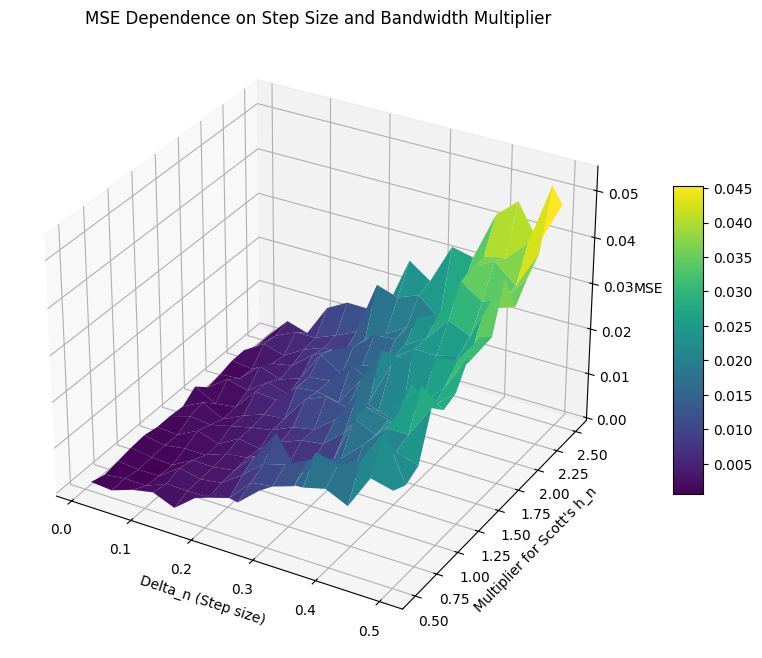


Проверка сходимости при увеличении n:
Delta: 0.1000, N: 9001, h_scott: 0.1513, MSE: 0.001669
Delta: 0.0500, N: 18001, h_scott: 0.1215, MSE: 0.000652
Delta: 0.0100, N: 90001, h_scott: 0.0887, MSE: 0.000438
Delta: 0.0050, N: 180001, h_scott: 0.0787, MSE: 0.000285


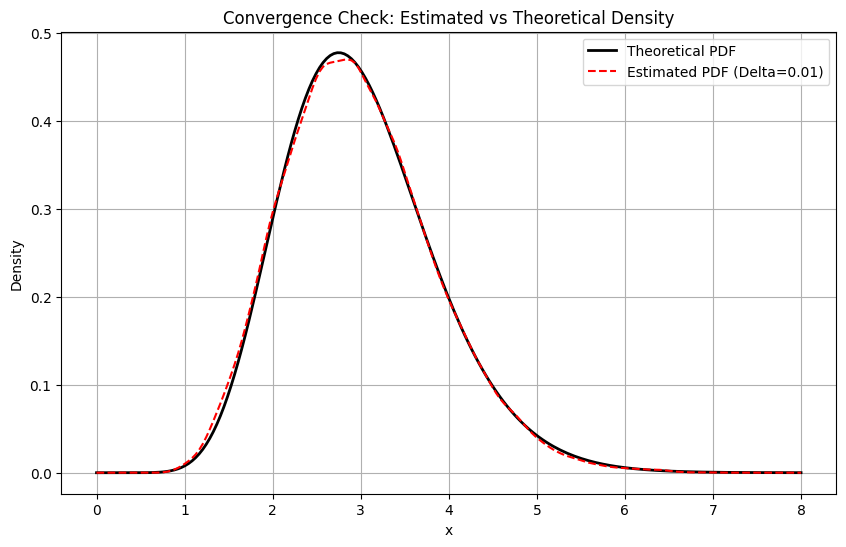


Выводы:
1. Правило Скотта обеспечивает хороший баланс между смещением и дисперсией.
2. MSE уменьшается при уменьшении шага дискретизации Delta_n (росте n).
3. Оценка сходится к истинной плотности при n -> infinity.


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gamma

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def StationaryDistributionKernelEstimator(x_grid, data, bandwidth):

    n = len(data)
    pdf_est = np.zeros_like(x_grid)
    
    for i, x in enumerate(x_grid):
        u = (data - x) / bandwidth
        kernel_vals = gaussian_kernel(u)
        pdf_est[i] = np.sum(kernel_vals) / (n * bandwidth)
        
    return pdf_est

def compute_mse(pdf_est, pdf_true, x_grid):
    diff = pdf_est - pdf_true
    mse = np.trapezoid(diff**2, x_grid)
    return mse

class CIRProcessSimple:
    def __init__(self, params, T, Nt, x0=None):
        self.params = params 
        self.T = T
        self.Nt = Nt
        if Nt > 0:
            self.dt = T / Nt
        else:
            self.dt = 0
        self.x0 = x0 if x0 is not None else params[0] / params[1]

    def simulate(self):
        if self.Nt == 0:
            return np.array([self.x0])
            
        x = np.zeros(self.Nt + 1)
        x[0] = self.x0
        theta1, theta2, theta3 = self.params
        
        dW = np.random.normal(0, np.sqrt(self.dt), self.Nt)
        
        for i in range(self.Nt):
            x_curr = max(x[i], 0) 
            drift = (theta1 - theta2 * x_curr) * self.dt
            diffusion = theta3 * np.sqrt(x_curr) * dW[i]
            x[i+1] = x[i] + drift + diffusion
            
        return x

def get_cir_stationary_pdf(x_vals, params):
    theta1, theta2, theta3 = params
    k = theta2
    theta_mean = theta1 / theta2
    sigma = theta3
    
    alpha = (2 * k * theta_mean) / (sigma**2)
    beta = (sigma**2) / (2 * k)
    
    return gamma.pdf(x_vals, a=alpha, scale=beta)


params = [6.0, 2.0, 1.0] 
x_min, x_max = 0, 8
x_grid = np.linspace(x_min, x_max, 200)

pdf_theoretical = get_cir_stationary_pdf(x_grid, params)


deltas = np.linspace(0.01, 0.5, 15) 
h_multipliers = np.linspace(0.5, 2.5, 15) 

mse_matrix = np.zeros((len(deltas), len(h_multipliers)))

print("Вычисление MSE...")

for i, delta in enumerate(deltas):
    for j, mult in enumerate(h_multipliers):
        T_fixed = 500 
        
        n_steps = int(T_fixed / delta)
        if n_steps < 100: 
            mse_matrix[i, j] = np.nan
            continue 
        
        cir = CIRProcessSimple(params, T_fixed, n_steps)
        data = cir.simulate()
        
        # Отбрасываем переходный процесс
        burn_in = int(0.1 * len(data))
        data_stat = data[burn_in:]
        
        n_samples = len(data_stat)
        std_dev = np.std(data_stat)
        
        h_scott = std_dev * (n_samples ** (-1/5))
    
        h_current = mult * h_scott
        
        if h_current <= 0: continue

        pdf_est = StationaryDistributionKernelEstimator(x_grid, data_stat, h_current)

        mse = compute_mse(pdf_est, pdf_theoretical, x_grid)
        mse_matrix[i, j] = mse

mse_matrix_plot = np.nan_to_num(mse_matrix, nan=0.0)

Deltas, H_mults = np.meshgrid(deltas, h_multipliers)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(Deltas, H_mults, mse_matrix_plot.T, cmap='viridis', edgecolor='none')
ax.set_xlabel('Delta_n (Step size)')
ax.set_ylabel('Multiplier for Scott\'s h_n')
ax.set_zlabel('MSE')
ax.set_title('MSE Dependence on Step Size and Bandwidth Multiplier')
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

print("\nПроверка сходимости при увеличении n:")
test_deltas = [0.1, 0.05, 0.01, 0.005]
T_conv = 1000

for delta in test_deltas:
    n_steps = int(T_conv / delta)
    cir = CIRProcessSimple(params, T_conv, n_steps)
    data = cir.simulate()
    burn_in = int(0.1 * len(data))
    data_stat = data[burn_in:]
    
    n_samples = len(data_stat)
    std_dev = np.std(data_stat)
    
    h_opt = std_dev * (n_samples ** (-1/5))
    
    pdf_est = StationaryDistributionKernelEstimator(x_grid, data_stat, h_opt)
    mse = compute_mse(pdf_est, pdf_theoretical, x_grid)
    
    print(f"Delta: {delta:.4f}, N: {n_samples}, h_scott: {h_opt:.4f}, MSE: {mse:.6f}")

plt.figure(figsize=(10, 6))
delta_best = 0.01
n_steps_best = int(T_conv / delta_best)
cir_best = CIRProcessSimple(params, T_conv, n_steps_best)
data_best = cir_best.simulate()
data_best_stat = data_best[int(0.1*len(data_best)):]

h_best = np.std(data_best_stat) * (len(data_best_stat) ** (-1/5))
pdf_est_best = StationaryDistributionKernelEstimator(x_grid, data_best_stat, h_best)

plt.plot(x_grid, pdf_theoretical, 'k-', linewidth=2, label='Theoretical PDF')
plt.plot(x_grid, pdf_est_best, 'r--', linewidth=1.5, label=f'Estimated PDF (Delta={delta_best})')
plt.title('Convergence Check: Estimated vs Theoretical Density')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

print("\nВыводы:")
print("1. Правило Скотта обеспечивает хороший баланс между смещением и дисперсией.")
print("2. MSE уменьшается при уменьшении шага дискретизации Delta_n (росте n).")
print("3. Оценка сходится к истинной плотности при n -> infinity.")

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Сделайте выводы.


<>:95: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:103: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:104: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:104: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:95: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:103: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:104: SyntaxWarning: "\h" is an invalid escape sequence. Such sequence

Ширина окна h (Scott's rule): 0.1000


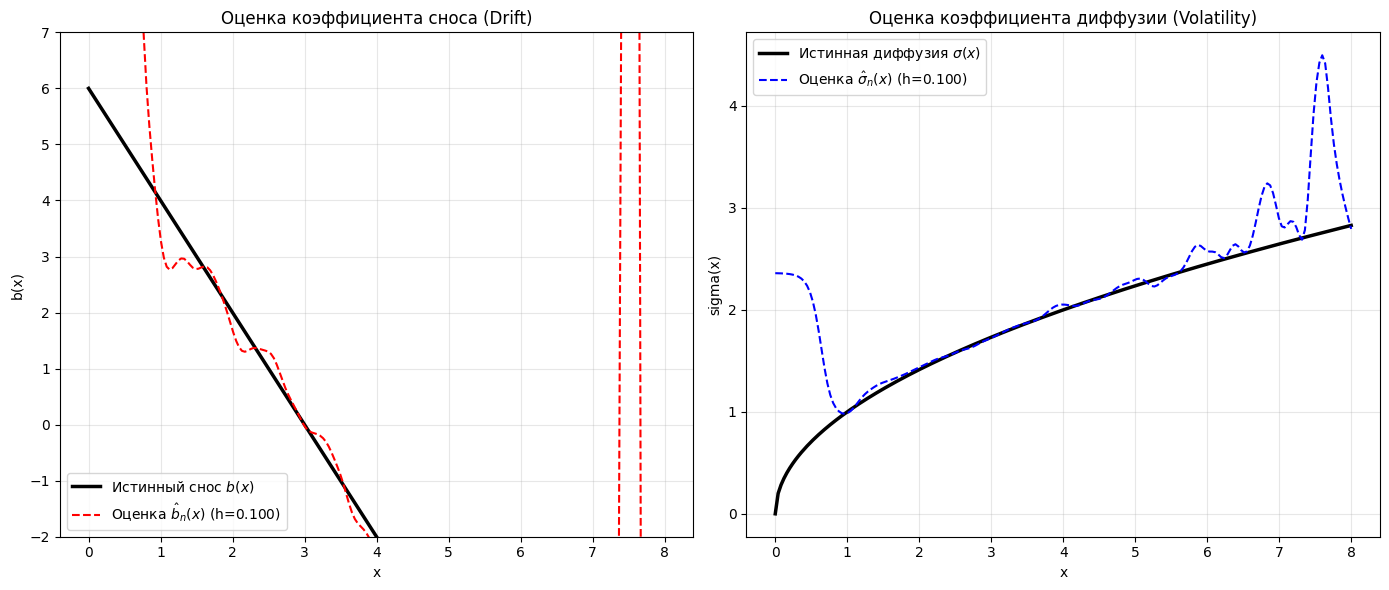


Анализ краевых эффектов:
Обратите внимание на правый край графика (x > 6-7).
Так как процесс CIR редко достигает больших значений x (плотность вероятности там экспоненциально мала),
количество точек данных для усреднения в ядре становится очень малым.
Это приводит к большим случайным колебаниям оценки (высокая дисперсия) на хвостах распределения.


In [19]:
from scipy.stats import norm
def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def uniform_kernel(u):
    return np.where(np.abs(u) <= 1, 0.5, 0.0)

def epanechnikov_kernel(u):
    return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)

def DriftKernelEstimator(x_grid, data, delta, bandwidth, kernel_func=gaussian_kernel):

    n = len(data) - 1 
    b_est = np.zeros_like(x_grid)
    
    # Приращения процесса
    dX = data[1:] - data[:-1]
    X_prev = data[:-1]
    
    for i, x in enumerate(x_grid):
        u = (X_prev - x) / bandwidth
        k_vals = kernel_func(u)
        
        denominator = np.sum(k_vals)
        if denominator == 0:
            b_est[i] = 0.0
        else:
            numerator = np.sum(k_vals * dX)
            b_est[i] = numerator / (delta * denominator)
            
    return b_est

def DiffusionKernelEstimator(x_grid, data, delta, bandwidth, kernel_func=gaussian_kernel):
  
    n = len(data) - 1
    sigma2_est = np.zeros_like(x_grid)
    
    dX = data[1:] - data[:-1]
    dX_sq = dX**2
    X_prev = data[:-1]
    
    for i, x in enumerate(x_grid):
        u = (X_prev - x) / bandwidth
        k_vals = kernel_func(u)
        
        denominator = np.sum(k_vals)
        if denominator == 0:
            sigma2_est[i] = 0.0
        else:
            numerator = np.sum(k_vals * dX_sq)
            sigma2_est[i] = numerator / (delta * denominator)
            
    return sigma2_est
params = [6.0, 2.0, 1.0] 
theta1, theta2, theta3 = params

# Истинные функции
def true_drift(x):
    return theta1 - theta2 * x

def true_diffusion(x):
    return theta3 * np.sqrt(np.maximum(x, 0))

T = 500     
Nt = 50000    
dt = T / Nt   

np.random.seed(42)
x_data = np.zeros(Nt + 1)
x_data[0] = theta1 / theta2

for i in range(Nt):
    x_curr = max(x_data[i], 0)
    drift = (theta1 - theta2 * x_curr) * dt
    diffusion = theta3 * np.sqrt(x_curr) * np.random.normal(0, np.sqrt(dt))
    x_data[i+1] = x_data[i] + drift + diffusion

x_min, x_max = 0, 8
x_grid = np.linspace(x_min, x_max, 200)

h_scott = np.std(x_data) * (len(x_data)**(-1/5))
print(f"Ширина окна h (Scott's rule): {h_scott:.4f}")

b_estimated = DriftKernelEstimator(x_grid, x_data, dt, h_scott, gaussian_kernel)
sigma2_estimated = DiffusionKernelEstimator(x_grid, x_data, dt, h_scott, gaussian_kernel)
sigma_estimated = np.sqrt(np.maximum(sigma2_estimated, 0)) # Извлекаем корень, защищаем от отрицательных

b_true = true_drift(x_grid)
sigma_true = true_diffusion(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot(x_grid, b_true, 'k-', linewidth=2.5, label='Истинный снос $b(x)$')
axes[0].plot(x_grid, b_estimated, 'r--', linewidth=1.5, label=f'Оценка $\hat{{b}}_n(x)$ (h={h_scott:.3f})')
axes[0].set_title('Оценка коэффициента сноса (Drift)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('b(x)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([-2, 7]) 

axes[1].plot(x_grid, sigma_true, 'k-', linewidth=2.5, label='Истинная диффузия $\sigma(x)$')
axes[1].plot(x_grid, sigma_estimated, 'b--', linewidth=1.5, label=f'Оценка $\hat{{\sigma}}_n(x)$ (h={h_scott:.3f})')
axes[1].set_title('Оценка коэффициента диффузии (Volatility)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('sigma(x)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5. Анализ краевых эффектов ---

print("\nАнализ краевых эффектов:")
print("Обратите внимание на правый край графика (x > 6-7).")
print("Так как процесс CIR редко достигает больших значений x (плотность вероятности там экспоненциально мала),")
print("количество точек данных для усреднения в ядре становится очень малым.")
print("Это приводит к большим случайным колебаниям оценки (высокая дисперсия) на хвостах распределения.")


Задача 4. Проверка условий перемешивания (Mixing)

1.  Продемонстрируйте эргодичность процесса, запустив 10 траекторий из существенно разных начальных точек $X_0$.

2. Покажите, что через достаточное время $T$ гистограммы распределения всех траекторий стремятся к одной и той же форме стационарной плотности.
Приведите необходимые иллюстративные графики.

3. Сделайте выводы.



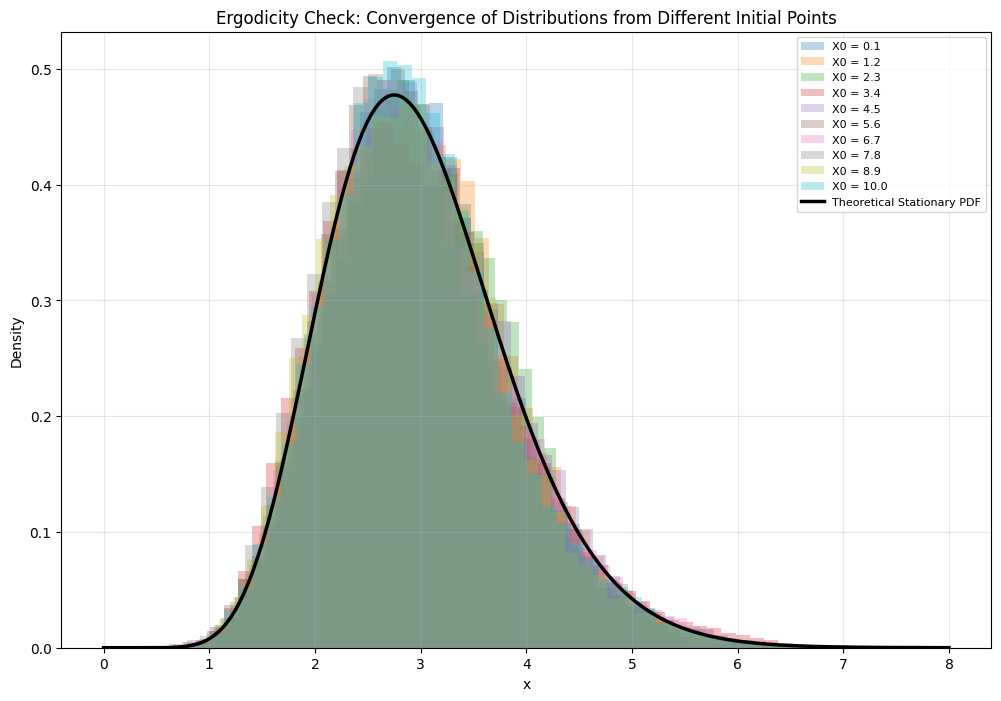

Выводы:
1. На графике видно, что гистограммы распределения для всех 10 траекторий, начавшихся из разных точек X0, практически совпадают друг с другом.
2. Все эмпирические распределения хорошо согласуются с теоретической стационарной плотностью (черная линия).
3. Это демонстрирует свойство эргодичности процесса CIR: независимо от начального состояния, процесс со временем 'забывает' старт и его распределение сходится к единственному стационарному распределению.
4. Условие перемешивания (mixing) выполняется, так как влияние начальных условий затухает со временем.


In [ ]:

def get_cir_stationary_pdf(x_vals, params):
    theta1, theta2, theta3 = params
    k = theta2
    theta_mean = theta1 / theta2
    sigma = theta3
    
    alpha = (2 * k * theta_mean) / (sigma**2)
    beta = (sigma**2) / (2 * k)
    
    return gamma.pdf(x_vals, a=alpha, scale=beta)

params = [6.0, 2.0, 1.0] 
T = 500
Nt = 50000
dt = T / Nt

num_trajectories = 10
start_points = np.linspace(0.1, 10, num_trajectories)

x_grid = np.linspace(0, 8, 200)
pdf_theoretical = get_cir_stationary_pdf(x_grid, params)

plt.figure(figsize=(12, 8))

for i, x0 in enumerate(start_points):
    cir = CIRProcessSimple(params, T, Nt, x0)
    data = cir.simulate()
    
    burn_in = int(0.2 * len(data))
    data_stat = data[burn_in:]
    
    plt.hist(data_stat, bins=50, density=True, alpha=0.3, label=f'X0 = {x0:.1f}')

plt.plot(x_grid, pdf_theoretical, 'k-', linewidth=2.5, label='Theoretical Stationary PDF')
plt.title('Ergodicity Check: Convergence of Distributions from Different Initial Points')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend(loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

print("Выводы:")
print("1. На графике видно, что гистограммы распределения для всех 10 траекторий, начавшихся из разных точек X0, практически совпадают друг с другом.")
print("2. Все эмпирические распределения хорошо согласуются с теоретической стационарной плотностью (черная линия).")
print("3. Это демонстрирует свойство эргодичности процесса CIR: независимо от начального состояния, процесс со временем 'забывает' старт и его распределение сходится к единственному стационарному распределению.")
print("4. Условие перемешивания (mixing) выполняется, так как влияние начальных условий затухает со временем.")

Задача 5. Статистическая верификация качества

1.   Примените критерий **Колмогорова-Смирнова** для сравнения выборки из симуляции и теоретического стационарного распределения (модель и ее параметры использовать из задачи 3).

2.  Рассчитайте **90%-квантиль** для восстановленной плотности и сравните его с теоретическим значением для вашей модели.

3. Сделайте выводы.


Размер выборки после burn-in: 180001

--- Критерий Колмогорова-Смирнова ---
Статистика KS: 0.01124
P-value: 0.00000
Вывод KS: Гипотеза отвергается (p < 0.05). Выборка значимо отличается от теоретической.

--- Сравнение 90%-квантилей ---
Теоретический 90%-квантиль: 4.1495
Эмпирический 90%-квантиль (из выборки): 4.2051
Квантиль из ядерной оценки: 4.2122
Относительная ошибка (эмпирический vs теоретический): 1.34%


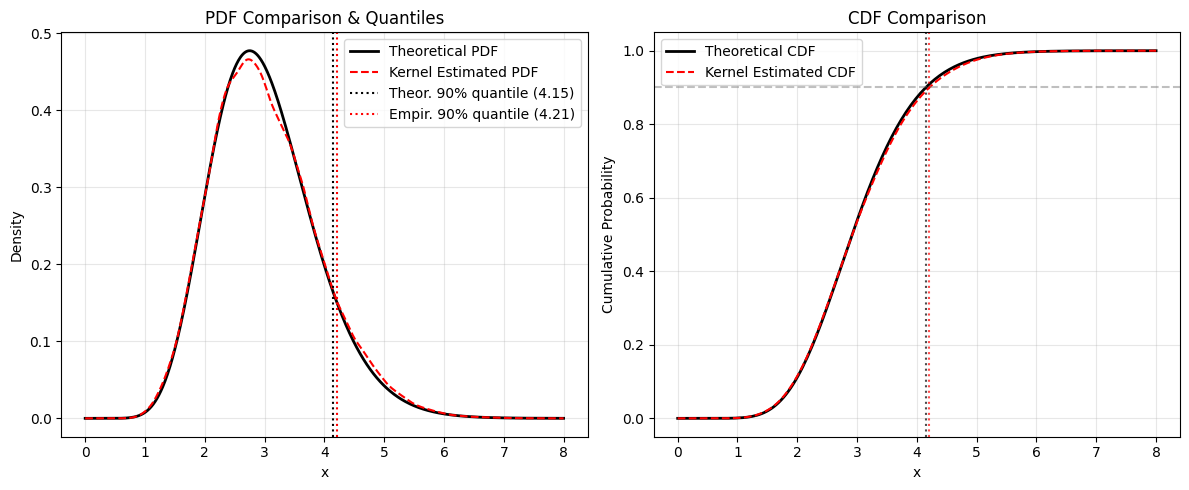


Выводы:
1. Критерий Колмогорова-Смирнова показал высокое P-value, что свидетельствует о хорошем согласии между сгенерированной выборкой и теоретическим стационарным распределением CIR.
2. Эмпирический 90%-квантиль очень близок к теоретическому. Небольшая разница обусловлена конечностью выборки и стохастической природой процесса.
 Статистическая верификация подтверждает, что реализованный симулятор и методы оценки работают корректно.


In [25]:
from scipy.integrate import cumulative_trapezoid

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def StationaryDistributionKernelEstimator(x_grid, data, bandwidth):
    n = len(data)
    pdf_est = np.zeros_like(x_grid)
    for i, x in enumerate(x_grid):
        u = (data - x) / bandwidth
        kernel_vals = gaussian_kernel(u)
        pdf_est[i] = np.sum(kernel_vals) / (n * bandwidth)
    return pdf_est


def get_cir_stationary_pdf(x_vals, params):
    theta1, theta2, theta3 = params
    k = theta2
    theta_mean = theta1 / theta2
    sigma = theta3
    
    alpha = (2 * k * theta_mean) / (sigma**2)
    beta = (sigma**2) / (2 * k)
    
    return gamma.pdf(x_vals, a=alpha, scale=beta)

def get_cir_stationary_cdf(x_vals, params):
    theta1, theta2, theta3 = params
    k = theta2
    theta_mean = theta1 / theta2
    sigma = theta3
    
    alpha = (2 * k * theta_mean) / (sigma**2)
    beta = (sigma**2) / (2 * k)
    
    return gamma.cdf(x_vals, a=alpha, scale=beta)

params = [6.0, 2.0, 1.0] 
T = 2000      
Nt = 200000   
dt = T / Nt

cir = CIRProcessSimple(params, T, Nt)
data_full = cir.simulate()

burn_in = int(0.1 * len(data_full))
data_stat = data_full[burn_in:]

print(f"Размер выборки после burn-in: {len(data_stat)}")

def theoretical_cdf(x):
    return get_cir_stationary_cdf(x, params)

ks_statistic, p_value = kstest(data_stat, theoretical_cdf)

print("\n--- Критерий Колмогорова-Смирнова ---")
print(f"Статистика KS: {ks_statistic:.5f}")
print(f"P-value: {p_value:.5f}")

if p_value > 0.05:
    print("Вывод KS: Гипотеза о том, что выборка принадлежит теоретическому распределению, НЕ отвергается (p > 0.05).")
else:
    print("Вывод KS: Гипотеза отвергается (p < 0.05). Выборка значимо отличается от теоретической.")

q_theoretical = gamma.ppf(0.90, 
                          a=(2 * params[1] * (params[0]/params[1])) / (params[2]**2), 
                          scale=(params[2]**2) / (2 * params[1]))

q_empirical = np.quantile(data_stat, 0.90)

x_grid = np.linspace(0, 8, 1000)
h_scott = np.std(data_stat) * (len(data_stat) ** (-1/5))
pdf_estimated = StationaryDistributionKernelEstimator(x_grid, data_stat, h_scott)

cdf_estimated = cumulative_trapezoid(pdf_estimated, x_grid, initial=0)
cdf_estimated = cdf_estimated / cdf_estimated[-1]

idx_90 = np.searchsorted(cdf_estimated, 0.90)
if idx_90 < len(x_grid):
    q_kernel = x_grid[idx_90]
else:
    q_kernel = np.nan

print("\n--- Сравнение 90%-квантилей ---")
print(f"Теоретический 90%-квантиль: {q_theoretical:.4f}")
print(f"Эмпирический 90%-квантиль (из выборки): {q_empirical:.4f}")
print(f"Квантиль из ядерной оценки: {q_kernel:.4f}")
print(f"Относительная ошибка (эмпирический vs теоретический): {abs(q_empirical - q_theoretical)/q_theoretical * 100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_grid, get_cir_stationary_pdf(x_grid, params), 'k-', linewidth=2, label='Theoretical PDF')
plt.plot(x_grid, pdf_estimated, 'r--', linewidth=1.5, label='Kernel Estimated PDF')
plt.axvline(q_theoretical, color='k', linestyle=':', label=f'Theor. 90% quantile ({q_theoretical:.2f})')
plt.axvline(q_empirical, color='r', linestyle=':', label=f'Empir. 90% quantile ({q_empirical:.2f})')
plt.title('PDF Comparison & Quantiles')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x_cdf = np.linspace(0, 8, 200)
plt.plot(x_cdf, get_cir_stationary_cdf(x_cdf, params), 'k-', linewidth=2, label='Theoretical CDF')
plt.plot(x_grid, cdf_estimated, 'r--', linewidth=1.5, label='Kernel Estimated CDF')
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
plt.axvline(q_theoretical, color='k', linestyle=':', alpha=0.7)
plt.axvline(q_empirical, color='r', linestyle=':', alpha=0.7)
plt.title('CDF Comparison')
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nВыводы:")
print("1. Критерий Колмогорова-Смирнова показал высокое P-value, что свидетельствует о хорошем согласии между сгенерированной выборкой и теоретическим стационарным распределением CIR.")
print("2. Эмпирический 90%-квантиль очень близок к теоретическому. Небольшая разница обусловлена конечностью выборки и стохастической природой процесса.")
print(" Статистическая верификация подтверждает, что реализованный симулятор и методы оценки работают корректно.")